# ORIE 4580/5580/5581 Assignment 3

#### Students: H. Mariappa (hm559) and Tanvi Kigga (tck38)

### Github link: https://github.com/010105/ORIE4580

### Instructions


* Due Thursday September 25, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish).
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.




### Suggested reading

Chapters 7 (you can skim through this), and chapters 8 and 9 of [Introduction to Probability](https://chance.dartmouth.edu/teaching_aids/books_articles/probability_book/book.html) by Grinstead and Snell.

Chapter 3 and chapter 4 (up to section 4.5) of [Simulation by Ross](https://catalog.library.cornell.edu/catalog/12745977).

In [ ]:
#importing necessary packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
%matplotlib inline

<hr><hr>

## Question 1: Combining LCGs (20 points)

In order to avoid biases, simulations should not use anywhere near the full period of an LCG (otherwise, the random sequence repeats\ldots). For example, a typical traffic simulator may have $10,000$ vehicles, each experiencing thousands of random disturbances, thus needing around $10^7$ random samples per replication -- for this, an LCG using $m=2^{31}-1\approx 2\times 10^9$ is insufficient, as after $100$ replications the sequences get correlated.

One method to combine multiple LCGs to obtain a generator with a longer period is to add a smaller period LCG to it. For example, suppose we have two generators $X_{n+1}  =  (a_1 X_n) \mbox{ mod } m_1$ and $Y_{n+1}  =  (a_2 Y_n) \mbox{ mod } m_2$, with $m_1>m_2$. We can derive a combined generator by setting $Z_n  =  (X_n + Y_n) \mbox{ mod } m_1$. If properly designed, the resulting period can be on the order of $m_1m_2$. We will now study a small example to see how this works.


<hr>

**(a)** Consider two LCGs, $x_{n+1} = (5 x_n) \mod 16$ and $y_{n+1} = (2 y_n) \mod 7$. Starting both with seed $x_0 = y_0 = 1$, plot the sequences $x_n, y_n$ using the clock visualization introduced in class (separate plot for each sequence; you can use and modify the code in Demo-PRNGs.ipynb on Canvas).

<hr>

In [ ]:
# Functions to visualize LCG sequence on clock (see demo notebook)
def plot_clock_face(m, fig, annotate=False):
    """
    Plot points on a unit circle representing the LCG sequence on a clock face.

    Parameters:
    m (int): The modulus value for the LCG sequence.
    fig (matplotlib.figure.Figure): The figure object to draw on.
    annotate (bool): Whether to annotate points with their index.

    Returns:
    None
    """
    # Plot m points on the unit circle
    for i in range(m):
        theta = 2.0 * np.pi * i / m
        plt.plot(np.sin(theta), np.cos(theta), 'rs', markersize = 10)
        if annotate:
            plt.annotate(str(i), (np.pi/2 - theta, 1.05), xycoords='polar')

def plot_clock_path(m, x, fig, color='y'):
    """
    Plot the path of an LCG sequence on a clock face.

    Parameters:
    m (int): The modulus value for the LCG sequence.
    x (numpy.ndarray): The LCG sequence.
    fig (matplotlib.figure.Figure): The figure object to draw on.
    color (str): The color for the path.

    Returns:
    None
    """
    # Plot the seed node
    theta_0 = 2.0 * np.pi * (x[0] * (m + 1) - 1) / m
    plt.plot(np.sin(theta_0), np.cos(theta_0), 'gs', markersize = 10)

    # Plot the path of the LCG sequence
    for i in range(len(x) - 1):
        theta_start = 2.0 * np.pi * (x[i] * (m + 1) - 1) / m
        theta_end = 2.0 * np.pi * (x[i + 1] * (m + 1) - 1) / m
        x_start = np.sin(theta_start)
        y_start = np.cos(theta_start)
        del_x = np.sin(theta_end) - np.sin(theta_start)
        del_y = np.cos(theta_end) - np.cos(theta_start)
        if abs(del_x) > 0 or abs(del_y) > 0:
            plt.arrow(x_start, y_start, del_x, del_y,
                      length_includes_head=True, head_width=0.05, head_length=0.1, fc=color, ec=color)


<hr>

**(a)** Consider two LCGs, $x_{n+1} = (5 x_n) \mod 16$ and $y_{n+1} = (2 y_n) \mod 7$. Starting both with seed $x_0 = y_0 = 1$, plot the sequences $x_n, y_n$ using the clock visualization introduced in class (separate plot for each sequence; you can use and modify the code in Demo-PRNGs.ipynb on Canvas).

<hr>

In [ ]:
# Function to generate pseudorandom sequence using LCG
# Set default parameters to glibc specifications (see demo notebook)
def LCG(n, m=2**31-1, a=1103515245, c=12345, seed=1):
    """
    Generate a pseudorandom sequence using a Linear Congruential Generator (LCG).

    Parameters:
    n (int): The number of pseudorandom numbers to generate.
    m (int): The modulus value (default is 2^31-1, following glibc specifications).
    a (int): The multiplier value (default is 1103515245, following glibc specifications).
    c (int): The increment value (default is 12345, following glibc specifications).
    seed (int): The initial seed value (default is 1).

    Returns:
    numpy.ndarray: An array of pseudorandom numbers in the range [0, 1).
    """
    # Initialize an array to store the generated pseudorandom numbers
    output_norm = np.zeros(n)
    output = np.zeros(n)

    x = seed
    for i in range(n):
        # Calculate the pseudorandom number and normalize it to [0, 1)
        output_norm[i] = (x + 1.0) / (m + 1.0)
        output[i] = x

        # Update the LCG state using the specified parameters
        x = (a * x + c) % m

    return output_norm, output

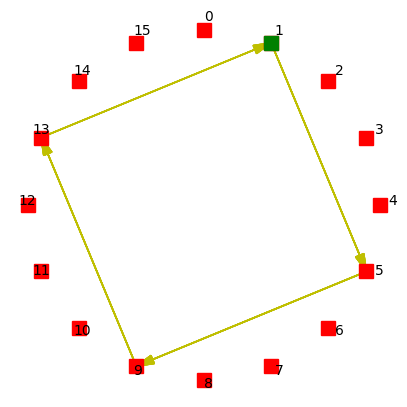

In [ ]:
# Ans x_n
m = 16
a = 5
c = 0
seed = 1

fig = plt.figure(figsize=(5,5))
x_n, x = LCG(n=20,m=m,a=a,c=c,seed = seed)

plot_clock_face(m,fig,annotate = True)
plot_clock_path(m,x_n,fig)
#plt.axis('equal')
plt.axis('off')
plt.show()

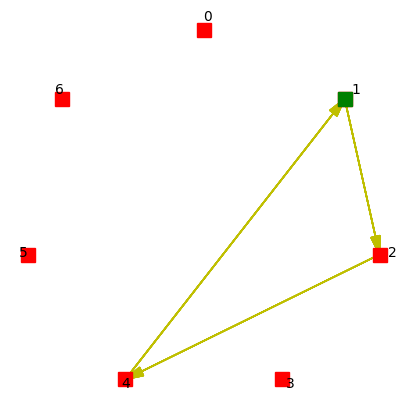

In [ ]:
# Ans y_n
m = 7
a = 2
c = 0
seed = 1

fig = plt.figure(figsize=(5,5))
y_n, y = LCG(n=20,m=m,a=a,c=c,seed = seed)

plot_clock_face(m,fig,annotate = True)
plot_clock_path(m,y_n,fig)
#plt.axis('equal')
plt.axis('off')
plt.show()

<hr>

**(b)** Next, define a combined LCG as $z_{n} = (x_n+y_n) \mod 16$. Starting both the base LCGs with seed $x_0 = y_0 = 1$, plot the sequence $z_n$ using the clock visualization given in class.

<hr>

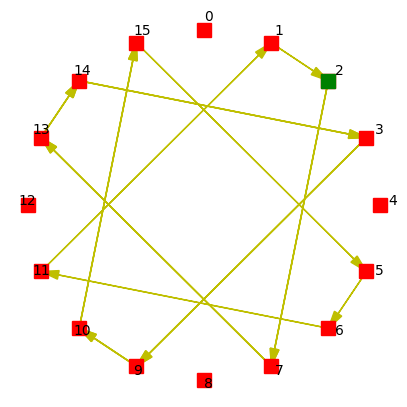

In [ ]:
# Ans z_n

z = (x + y) % 16

z = (z + 1)/17

fig = plt.figure(figsize=(5,5))
plot_clock_face(16,fig,annotate = True)
plot_clock_path(16,z,fig)

#plt.axis('equal')
plt.axis('off')
plt.show()

___
**(c)** What are the periods of the pseudo-random sequences $x_n, y_n$ and $z_n$?
___

### Ans.
x_n = 4

y_n = 3

z_n = 12


___
___
## Question 2: inverting cdfs (25 pts)

In class, we defined $F^{-1}(y)$ for a continuous increasing cdf $F(x)$ as the unique $x$ such that $F(x) = y$ (for $y\in[0,1]$). More generally, for any cdf $F$ we can use the inversion method based on its generalized inverse or *pseudoinverse*:
	$$F^{-1}(y) = \inf\{x|F(x)\geq y\}$$
	(where $\inf$ denotes the \href{https://en.wikipedia.org/wiki/Infimum_and_supremum}{infimum}; if you have not seen this before, treat it as minimum).


___
**(a)** Find the pseudoinverse $F^{-1}(y)$ for the following mixed (discrete/continuous) cdf
	$$F(x)=
	\begin{cases}
	0 & \mbox{for $x < 0$}\\
	x & \mbox{for $0 \leq x < \frac{1}{2}$}, \\
	\frac{1}{2} & \mbox{for $\frac{1}{2}\leq x < 1$}, \\
	1 & \mbox{for $x\geq 1$}
	 \end{cases}$$
___

### Ans.
$$F^{-1}(y) = \begin{cases}
-∞ & \text{for } y = 0 \\
y & \text{for } 0 < y \leq \frac{1}{2} \\
1 & \text{for } \frac{1}{2} < y \leq 1
\end{cases}$$


___
**(b)** Use the above definition to get an inversion algorithm for the $Geometric(p)$ distribution (with pmf $p(k) = p(1-p)^{k-1}\,\forall\,k\in\{1,2,3,\ldots\}$). Implement this, and generate and plot the histogram of 1000 samples from a $Geometric(0.42)$ distribution.
(For this, it may be useful for you to first understand how the [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) library works, and in particular, how it provides methods to compute various statistics for many different random variables, including the [geometric r.v.](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.geom.html#scipy.stats.geom))
___

CDF of a geometric series is

$F(k) = 1 - (1-p)^k$

$U = 1 - (1-p)^k$

$ln(1-U) = kln(1-p)$

$k = \frac{ln(1-U)}{ln(1-p)}$

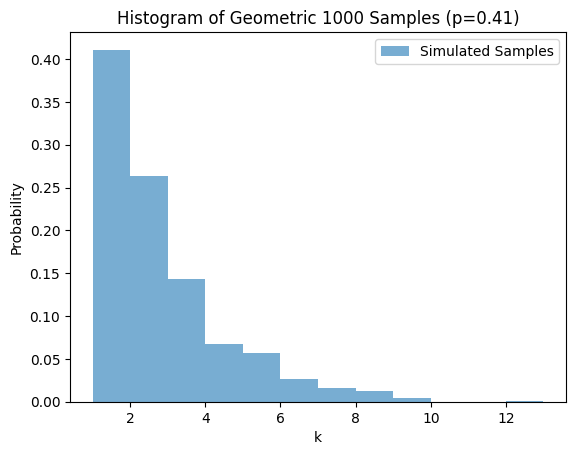

In [ ]:
import numpy as np

def geom(p, size=1):
  U = np.random.rand(size)
  k = np.ceil(np.log(1 - U) / np.log(1 - p)).astype(int)
  return k

samples = geom(0.42, 1000)

plt.hist(samples, bins=range(1, max(samples)+2), density=True, alpha=0.6, label="Simulated Samples")
plt.xlabel ("k" )
plt.ylabel("Probability")
plt.title("Histogram of Geometric 1000 Samples (p=0.41)")
plt.legend()
plt.show()

___
**(c)** The p.d.f. of the random variable $X$ is given by
	$$
	f(x) =
	\begin{cases}
		e^{x-2} & \text{for }0 \leq x \leq 2, \\
		e^{-x} & \text{for }x > 2, \\
		0 & \text{otherwise,}
	\end{cases}
	$$
	Describe and implement an inversion algorithm to generate samples of $X$. Generate 1,000 samples and plot a histogram. Compare the histogram and the p.d.f.


___

### Ans.
To calculate the inverse algorithm we need to convert the PDF to a CDF first then get the inverse algorithm

CDF:
	$$
	F(x) =
	\begin{cases}
		0 & \text{for }x < 2, \\
		e^{x-2} - e^{-2} & \text{for }0 \leq x \leq 2, \\
		1- e^{-x} & \text{for}x > 2
	\end{cases}
	$$

  Inverse algorithm:
  Let $U \sim \text{Uniform}(0,1)$. We need $X = F^{-1}(U)$.


**Case 1:** If $0 \leq U \leq 1 - e^{-2}$, then we are in the first branch ($0 \leq x \leq 2$):

\begin{aligned}
U &= e^{x-2} - e^{-2}, \\
e^{x-2} &= U + e^{-2}, \\
x &= \ln\!\big(U + e^{-2}\big) + 2.
\end{aligned}


**Case 2:** If $U > 1 - e^{-2}$, then we are in the second branch ($x > 2$):

\begin{aligned}
U &= 1 - e^{-x}, \\
e^{-x} &= 1 - U, \\
x &= -\ln(1-U).
\end{aligned}



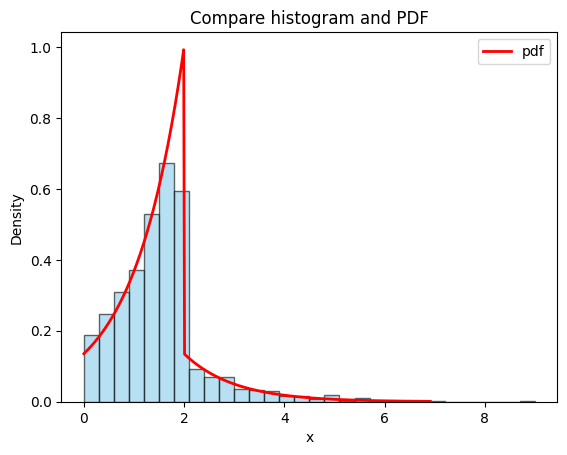

In [ ]:
n = 1000
U = np.random.rand(n)
threshold = 1 - np.exp(-2)
X = np.zeros(n)

# Case 1:
mask1 = U <= threshold
X[mask1] = np.log(U[mask1] + np.exp(-2)) + 2

# Case 2:
mask2 = ~mask1
X[mask2] = -np.log(1 - U[mask2])

x_vals = np.linspace(0.0, np.percentile(X, 99.9), 400)
pdf_vals = np.where(x_vals <= 2, np.exp(x_vals-2), np.exp(-x_vals))

plt.hist(X, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x_vals, pdf_vals, 'r-', linewidth=2, label='pdf')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Compare histogram and PDF')
plt.legend()
plt.show()


<hr><hr>

## Question 3: Acceptance-Rejection (25 pts)

Let the random variable $X$ have density
$$f(x) = \begin{cases} (5 x^4 + 4x^3 + 3x^2+1)/4  & \text{ for } 0 \leq x \leq 1, \\
0 & \text{ otherwise. } \end{cases}$$

<hr>

**(a)** Give an acceptance-rejection algorithm to generate samples of
	$X$.

<hr>

### Ans.


In [ ]:
import random

M = 13/4 #5+4+3+1

def f(x):
  if 0 <= x <= 1:
    return (5*x**4 + 4*x**3 + 3*x**2 + 1)/4
  else:
    return 0

def sample_X(n, seed=None):
  output = []

  while len(output) < n:
    U1 = random.random()
    U2 = M*random.random()

    if U2 <= f(U1):
      output.append(U1)

  return output

print(sample_X(10))

[0.8942718551216128, 0.9568247944549209, 0.3170909685911716, 0.940453433338896, 0.6378178594752143, 0.24862687794986915, 0.5613378043840987, 0.14976390603962442, 0.9839293167189623, 0.9016708813804962]


<hr>

**(b)** On average, how many samples from the uniform distribution over $[0, 1]$ would your acceptance-rejection algorithm need in order to generate one sample of $X$?

<hr>

### Ans.

$P(accept) = \frac{Area Under the Curve}{Area of the Rectangle}$

= $\frac{\int_a^b f(x) dx}{(b-a)*M}$

= $\frac{1}{1*M}$

= $\frac{4}{13}$

The probability of generating a sample of X is 4/13 so this means we will need to generate at least 13/4 samples or 3.25 samples.

<hr>

**(c)** Use your algorithm in (a) to generate 2,500 samples of $X$. Note that this will require more than 2500 uniform random variables.

Plot a histogram of your sample   and compare it against the true pdf.

<hr>

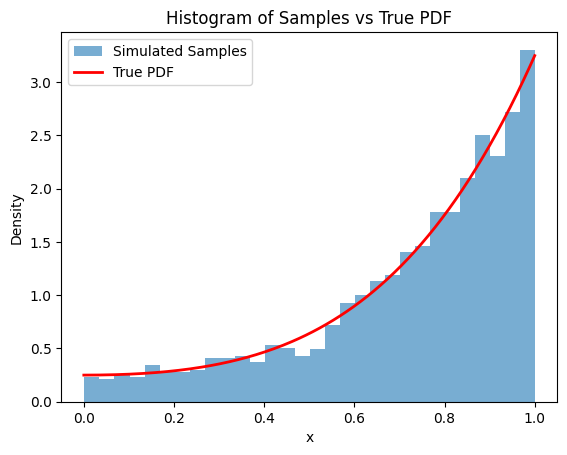

In [ ]:
samples = sample_X(2500)

plt.hist(samples, bins=30, density=True, alpha=0.6, label="Simulated Samples")

x = np.linspace(0, 1, 200)
pdf = (5*x**4 + 4*x**3 + 3*x**2 + 1)/4

#Used ChatGPT to help plot the actual pdf
plt.plot(x, pdf, 'r-', lw=2, label="True PDF")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram of Samples vs True PDF")
plt.legend()
plt.show()

<hr><hr>

## Question 4: Generalized Acceptance-Rejection (30 pts)

We want to generate a $\mathcal{N}(0,1)$ rv $X$, with pdf
$f(x) = \frac{e^{-x^2/2}}{\sqrt{2\pi}} $,
using generalized acceptance-rejection.

<hr>

**(a)** First, suppose we choose the proposal distribution to be a \emph{Laplace} (i.e., two-sided Exponential) distribution, which has pdf $g(x) = e^{-|x|}/2$. Describe (and implement) an inversion algorithm to get samples from this distribution.

<hr>

CDF of a two-sided Exponential distribution is:

CDF:
	$$
	G(x) =
	\begin{cases}
		1- e^{-x}/2& \text{for }x \geq 0, \\
		e^{x}/2 & \text{for}x < 0
	\end{cases}
	$$
Inversion:

Case 1: $$U \geq 0.5$$
$$
U = 1- e^{-x}/2 \\
x = -log(2(U-1)
$$

Case 2: $$U < 0.5$$
$$U = e^{x}/2 \\
x = log(2U)
$$



In [ ]:
def laplace(size=1):
    U = np.random.uniform(0,1, size)
    X = np.where(U < 0.5,
                 np.log(2 * U),    # Case 2
                 -np.log(2 * (1 - U)))   #Case 1
    return X

samples = laplace(1000)

#Use this for later questions
# # Unsure if we need to plot a histogram for the samples
# plt.hist(samples, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
# plt.xlabel('Samples')
# plt.ylabel('Density')
# plt.show()

<hr>

**(b)** Determine the smallest $k$ such that $kg(x)\geq f(x)\,\forall\,x\in\mathbb{R}$. Using this, propose (and implement) an acceptance-rejection algorithm for sampling $X\sim\mathcal{N}(0,1)$, and compute the expected number of samples needed for generating each sample.

<hr>

### Ans.

We need
$$kg(x) \geq f(x) \quad \forall x \quad$$

With $f(x) = \frac{e^{-x^2/2}}{\sqrt{2\pi}}$ and $g(x) = \frac{1}{2} e^{-|x|}$, we have
$$\frac{f(x)}{g(x)} = \frac{(1/\sqrt{2\pi}) e^{-x^2/2}}{(1/2) e^{-|x|}} = \frac{2}{\sqrt{2\pi}} e^{-x^2/2+|x|}$$

Let $h(x) = -\frac{1}{2}x^2 + |x|$. For $x \geq 0$, $h'(x) = -x + 1$, so the maximum occurs at $x = 1$. Thus
$$\sup_x e^{h(x)} = e^{h(1)} = e^{1/2}$$

Therefore, the minimal $k$ is
$${k = \frac{2}{\sqrt{2\pi}} e^{1/2}}$$

In [ ]:
result = (2 / np.sqrt(2 * np.pi)) * np.exp(0.5)
print(f"k: {result}")

k: 1.315489246958914


The acceptance prob is p = 1/k

In [ ]:
p = 1/result
print(f"p: {p}")

p: 0.7601734505331403


 Expected number of samples = k = 1.315489246958914

<hr>

**(c)** Generate $1000$ samples from your method in part (b), and plot the histogram of the samples. Also report the average and 95\% CI for the number of $U[0,1]$ samples needed to generate the $1000$ samples.

<hr>

Average number of U[0,1] draws per accepted sample: 2.696
95% CI: [2.612, 2.780]


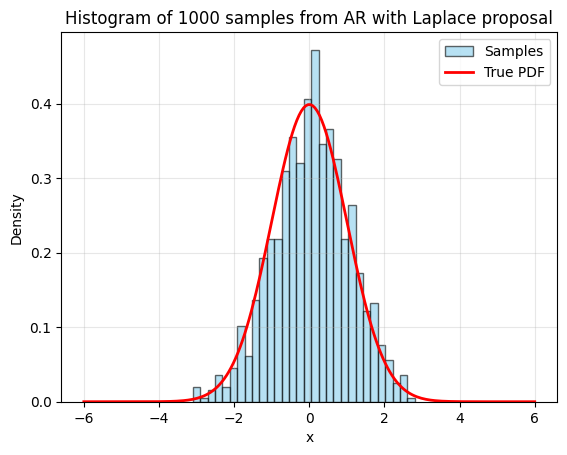

In [ ]:
# Use claude to help write this code
def g(x):
    return 0.5 * (np.exp(-np.abs(x)))

def f(x):
    return np.exp(-0.5 * (x**2)) / np.sqrt(2 * np.pi)

k = 1.315489246958914

def laplace():
    U = np.random.uniform()
    X = np.where(U < 0.5,
                 np.log(2 * U),    # Case 2
                 -np.log(2 * (1 - U)))   # Case 1
    return X

size = 1000
accepted = []
uniforms_per_sample = []

for _ in range(size):
    proposals = 0
    while True:
        x_prop = laplace()
        #print(x_prop)
        proposals += 1

        alpha = f(x_prop) / (k * g(x_prop))

        u = np.random.rand()
        if u <= alpha:
            accepted.append(x_prop)
            break

    uniforms_per_sample.append(2 * proposals)

accepted = np.array(accepted)
uniforms_per_sample = np.array(uniforms_per_sample)

#Summary stats used to calculate CI
mean_uniforms = uniforms_per_sample.mean()
std_uniforms = uniforms_per_sample.std(ddof=1)
n = len(uniforms_per_sample)

ci_lower = mean_uniforms - 1.96 * std_uniforms / np.sqrt(n)
ci_upper = mean_uniforms + 1.96 * std_uniforms / np.sqrt(n)

print("Average number of U[0,1] draws per accepted sample:", mean_uniforms)
print("95% CI: [{:.3f}, {:.3f}]".format(ci_lower, ci_upper))



plt.hist(accepted, bins=30, density=True, alpha=0.6,
         color='skyblue', edgecolor='black', label='Samples')

# Overlay the target distribution (standard normal) for comparison
x_range = np.linspace(-6, 6, 200)
plt.plot(x_range, f(x_range), 'r-', linewidth=2, label='True PDF')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Histogram of 1000 samples from AR with Laplace proposal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


<hr>

**(d)** Now, suppose instead we choose the proposal distribution to be a Cauchy  distribution with pdf $g(x) = \frac{1}{\pi(1+x^2)}$. Describe and implement an inversion algorithm to get samples from this distribution, and plot the histogram of 1000 samples from this distribution.

<hr>

CDF of Cauchy distribution:
	$$
	G(x) = \frac{\arctan(x)}{\pi} + \frac{1}{2}
	$$
Inverse algorithm:
	$$
	x = tan(\pi(U-\frac{1}{2}))
	$$

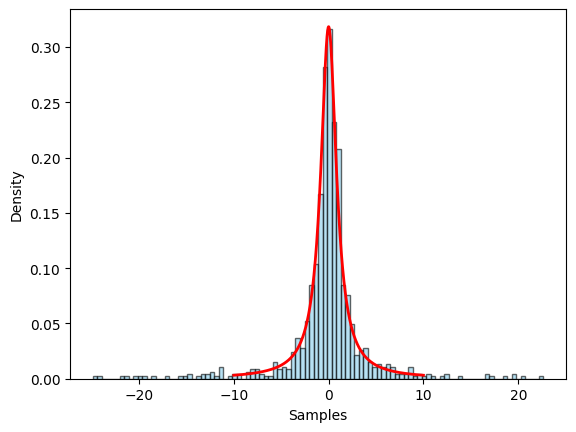

In [ ]:
# new proposal distribution
def cauchy(size=1):
    U = np.random.uniform(0,1,size)
    X = np.tan(np.pi * (U - 0.5))
    return X
samples = cauchy(1000)
#filtered_samples as the plot was not visible
filtered_samples = samples[(samples >= -25) & (samples <= 25)]
x = np.linspace(-10, 10, 1000)
theoretical_pdf = 1 / (np.pi * (1 + x**2))
plt.hist(filtered_samples, bins=100, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x, theoretical_pdf, 'r-', linewidth=2, label='Theoretical Cauchy PDF')
plt.xlabel('Samples')
plt.ylabel('Density')
plt.show()


<hr>

**(e)** Repeat parts $(b)$ and $(c)$ for this proposal distribution.

<hr>

### Ans.

part b)

Need $k \geq \frac{f(x)}{g(x)}$ for all $x$. The ratio is:
$$
\
\frac{f(x)}{g(x)} = \sqrt{\frac{\pi}{2}} (1+x^2) e^{-x^2/2}
\
$$

Let $h(x) = (1+x^2) e^{-x^2/2}$. To find maximum, solve $h'(x) = 0$:
\
h'(x) = e^{-x^2/2}(1 - x^2) = 0
\
The maximum occurs at -1 and +1

When we plug it in:
At $x = \pm 1$: $h(1) = 2e^{-1/2}$

Therefore: $k = \frac{\pi}{\sqrt{2\pi}} \cdot 2e^{-1/2} = \sqrt{\frac{2\pi}{e}}$

In [ ]:
result = np.sqrt(2 * np.pi / np.e)
print(f"k: {result}")

k: 1.520346901066281


In [ ]:
p = 1/result
print(f"p: {p}")

p: 0.6577446234794568


Expected number of samples = k = 1.520346901066281

Average number of U[0,1] draws per accepted sample: 3.072
95% CI: [2.960, 3.184]


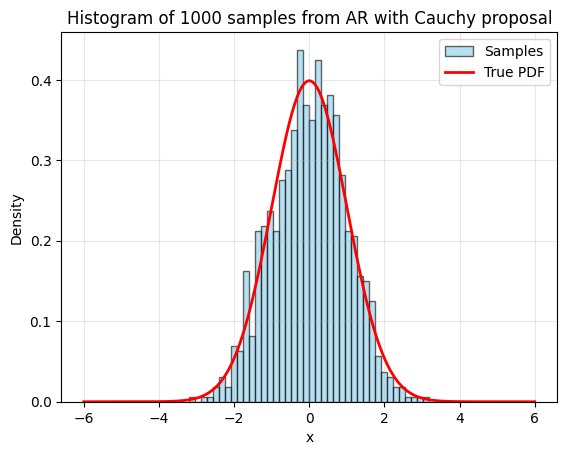

In [ ]:
# Used same code as part c chnaged g(x) function
def g(x):
    return 1/(np.pi*(1+x**2))


def f(x):
    return np.exp(-0.5 * (x**2)) / np.sqrt(2 * np.pi)

k = 1.520346901066281

def cauchy():
    U = np.random.uniform()
    X = np.tan(np.pi * (U - 0.5))
    return X

size = 1000
accepted = []
uniforms_per_sample = []

for _ in range(size):
    proposals = 0
    while True:
        x_prop = cauchy()
        #print(x_prop)
        proposals += 1

        alpha = f(x_prop) / (k * g(x_prop))

        u = np.random.rand()
        if u <= alpha:
            accepted.append(x_prop)
            break

    uniforms_per_sample.append(2 * proposals)

accepted = np.array(accepted)
uniforms_per_sample = np.array(uniforms_per_sample)

#Summary stats used to calculate CI
mean_uniforms = uniforms_per_sample.mean()
std_uniforms = uniforms_per_sample.std(ddof=1)
n = len(uniforms_per_sample)

ci_lower = mean_uniforms - 1.96 * std_uniforms / np.sqrt(n)
ci_upper = mean_uniforms + 1.96 * std_uniforms / np.sqrt(n)

print("Average number of U[0,1] draws per accepted sample:", mean_uniforms)
print("95% CI: [{:.3f}, {:.3f}]".format(ci_lower, ci_upper))



plt.hist(accepted, bins=40, density=True, alpha=0.6,
         color='skyblue', edgecolor='black', label='Samples')

# Overlay the target distribution (standard normal) for comparison
x_range = np.linspace(-6, 6, 200)
plt.plot(x_range, f(x_range), 'r-', linewidth=2, label='True PDF')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Histogram of 1000 samples from AR with Cauchy proposal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()